In [3]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import  scipy
from scipy.stats.mstats import winsorize
from sklearn.model_selection import train_test_split

In [4]:
# DATA_DIR = Path("../data")

In [5]:
# product_df = pd.read_csv(
#     DATA_DIR / "PublicTablesForCarbonCatalogueDataDescriptor_v30Oct2021(Product Level Data).csv",
#     encoding="latin1"
# )
product_df = pd.read_csv(
   "/workspaces/hi/ProductLevel.csv",
    encoding="latin1"
)


In [6]:
print(f"Product Dataset:  {product_df.shape}")


Product Dataset:  (866, 25)


In [7]:
product_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 866 entries, 0 to 865
Data columns (total 25 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   *PCF-ID                                    866 non-null    str    
 1   Year of reporting                          866 non-null    int64  
 2   *Stage-level CO2e available                866 non-null    str    
 3   Product name (and functional unit)         866 non-null    str    
 4   Product detail                             856 non-null    str    
 5   Company                                    866 non-null    str    
 6   Country (where company is incorporated)    866 non-null    str    
 7   Company's GICS Industry Group              866 non-null    str    
 8   Company's GICS Industry                    866 non-null    str    
 9   *Company's sector                          866 non-null    str    
 10  Product weight (kg)                  

In [8]:



product_data_summary = pd.DataFrame({
    'Source_Table': 'product_df',
    'Column_Name': product_df.columns,
    'Non_Null_Count': product_df.notnull().sum().values,
    'Unique_Values': product_df.nunique().values,
    'Data_Type': product_df.dtypes.values
})







display(product_data_summary)

,Source_Table,Column_Name,Non_Null_Count,Unique_Values,Data_Type
0,product_df,*PCF-ID,866,866,str
1,product_df,Year of reporting,866,5,int64
2,product_df,*Stage-level CO2e available,866,2,str
3,product_df,Product name (and functional unit),866,672,str
4,product_df,Product detail,856,496,str
5,product_df,Company,866,145,str
6,product_df,Country (where company is incorporated),866,28,str
7,product_df,Company's GICS Industry Group,866,30,str
8,product_df,Company's GICS Industry,866,35,str
9,product_df,*Company's sector,866,8,str


In [9]:
product_df['Year of reporting'].value_counts().sort_index()

Year of reporting
2013    179
2014    190
2015    217
2016    218
2017     62
Name: count, dtype: int64

Year was retained as a numerical feature because it represents an ordered temporal variable. Preserving its integer values allows machine learning algorithms to learn potential temporal trends without introducing unnecessary feature transformations.

In [10]:
product_df['*Stage-level CO2e available'].value_counts()

*Stage-level CO2e available
No     445
Yes    421
Name: count, dtype: int64

In [11]:
product_df['Country (where company is incorporated)'].value_counts()

Country (where company is incorporated)
USA               305
Japan             110
Germany            67
Taiwan             60
Finland            35
Netherlands        35
United Kingdom     32
Switzerland        28
Sweden             26
Italy              23
South Korea        22
France             20
Brazil             17
India              16
Spain              13
South Africa       11
Belgium             8
China               6
Canada              6
Ireland             6
Australia           6
Malaysia            4
Chile               3
Colombia            2
Luxembourg          2
Lithuania           1
Indonesia           1
Greece              1
Name: count, dtype: int64

### Drop replace by Region

In [12]:
product_df["Company's GICS Industry Group"].value_counts()

Company's GICS Industry Group
Technology Hardware & Equipment                                         195
Materials                                                               161
Food, Beverage & Tobacco                                                101
Automobiles & Components                                                 73
Consumer Durables & Apparel                                              52
Commercial & Professional Services                                       42
Capital Goods                                                            33
Chemicals                                                                29
Software & Services                                                      27
Food & Staples Retailing                                                 24
Textiles, Apparel, Footwear and Luxury Goods                             16
Media                                                                    15
Food & Beverage Processing                                

In [13]:
product_df["Company's GICS Industry"].value_counts()

Company's GICS Industry
Not used for 2015 reporting                       215
Chemicals                                          82
Computers & Peripherals                            70
Beverages                                          70
Electronic Equipment, Instruments & Components     47
Commercial Services & Supplies                     42
Auto Components                                    38
Paper & Forest Products                            34
Textiles, Apparel & Luxury Goods                   31
Food Products                                      30
Containers & Packaging                             28
Office Electronics                                 24
Household Durables                                 21
Metals & Mining                                    16
Software                                           14
Electrical Equipment                               14
Food & Staples Retailing                           14
Automobiles                                        13
Medi

"Provides reliable granular industry classification (30 well-defined groups) without structural missingness. Captures mid-level manufacturing and operational carbon baselines."

In [14]:
product_df["*Company's sector"].value_counts()

*Company's sector
Computer, IT & telecom                  253
Food & Beverage                         139
Home durables, textiles, & equipment    122
Chemicals                               116
Automobiles & components                 75
Construction & commercial materials      67
Comm. equipm. & capital goods            56
Packaging for consumer goods             38
Name: count, dtype: int64

Highly dense, zero-missingness high-level economic categorization (8 primary sectors). Serves as an ideal top-tier categorical driver for baseline PCF differentiation.

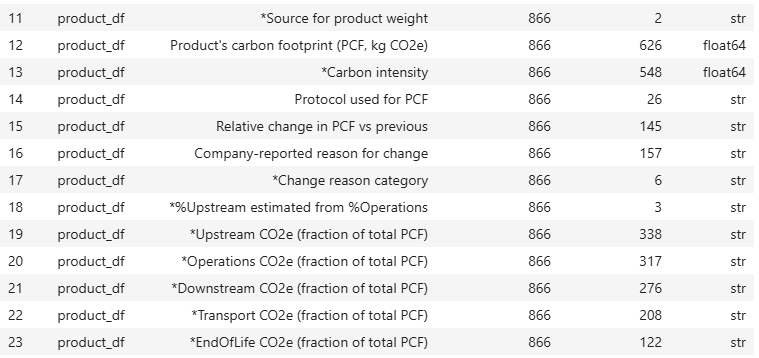

In [15]:
product_df['Protocol used for PCF'].value_counts()

Protocol used for PCF
ISO                            353
GHGP                           183
Not reported                   179
PAS2050                         73
TRACI 2.1                       20
Paper Profile                   12
MIT PAIA                         9
ILCD Handbook                    8
M. Env. Japan                    4
EcoLeaf                          4
Japan CFP                        2
EICC Tool                        2
EUPEF                            2
CEPI                             2
Carbon Labeling Certificate      2
WBCSD                            1
French PEF                       1
FEFCO                            1
Traci 2.1                        1
JRM Assoc.                       1
Korea CL Guide                   1
JEC/BIOGRACE                     1
CFP Japan                        1
EPD                              1
Bilan Carbone                    1
M. Env. Japan v2.2               1
Name: count, dtype: int64

In [16]:
product_df['*Change reason category'].value_counts()

*Change reason category
N/a (no %change reported)                                 482
Product carbon efficiency changed                         166
N/a (no previous data available)                          134
No specific reason reported                                38
Model and/or parameters changed (but not product)          25
Model/parameters AND product carbon efficiency changed     21
Name: count, dtype: int64

Dropped (*Change reason category): Over 75.5% of the records contain non-informative or missing entries (N/a (no %change reported), N/a (no previous data available), and No specific reason reported).

In [17]:
product_df['*%Upstream estimated from %Operations'].value_counts()

*%Upstream estimated from %Operations
N/a (product with insufficient stage-level data)    445
No                                                  317
Yes                                                 104
Name: count, dtype: int64

"Dropped (*%Upstream estimated from %Operations): Over 51.4% of the dataset contains missing or uninformative values (N/a (product with insufficient stage-level data)). Additionally, this feature represents an estimation flag used during data compilation rather than an intrinsic physical or supply-chain attribute of the product. Structural stage availability is already captured via engineered LCA stage metadata."

## Feature Selection 

| Feature                    | Encoding                                      |
| -------------------------- | --------------------------------------------- |
| Year                       | Numeric                                       |
| Product_Weight             | Numeric                                       |
| Region                     | One-Hot                                       |
| Industry (rare → Other)    | One-Hot                                       |
| PCF_Protocol               | One-Hot (or rare → Other → One-Hot if needed) |
| Stage_Level_CO2e_Available | Binary                                        |
| **Company**                | **Target Encoding**                           |
| PCF                        | Target                                        |


In [18]:
product_df = product_df.rename(columns={
    "Year of reporting": "Year",

    "Company": "Company",
    "Country (where company is incorporated)": "Country",
    "Company's GICS Industry": "Industry",

    "Product weight (kg)": "Product_Weight",

    "Protocol used for PCF": "PCF_Protocol",

    "*Stage-level CO2e available": "Stage_Level_CO2e_Available",

    "Product's carbon footprint (PCF, kg CO2e)": "PCF"
})

In [19]:

productclean_df = product_df[[
    "Year",
    "Company",
    "Stage_Level_CO2e_Available",
    "Country",
    "Industry",
    "Product_Weight",
    "PCF_Protocol",
    "PCF"
]].copy()

In [20]:
productclean_df.head()

,Year,Company,Stage_Level_CO2e_Available,Country,Industry,Product_Weight,PCF_Protocol,PCF
0,2014,Kellogg Company,Yes,USA,Food Products,0.7485,Not reported,2.00
1,2015,Kellogg Company,Yes,USA,Not used for 2015 reporting,0.7485,Not reported,2.00
2,2013,KNOLL INC,Yes,USA,Building Products,20.6800,Not reported,72.54
3,2017,"Konica Minolta, Inc.",Yes,Japan,"Electronic Equipment, Instruments & Components",110.0000,ISO,1488.00
4,2017,"Konica Minolta, Inc.",Yes,Japan,"Electronic Equipment, Instruments & Components",110.0000,ISO,1818.00


In [21]:
# productclean_df.to_csv(
#     "/workspaces/pcf-quality-framework/BEACON-PCF/data/productclean_df.csv",
#     index=False
# )

productclean_df.to_csv(
    "/workspaces/hi/productclean_df.csv",
    index=False
)

In [22]:
missing = productclean_df.isnull().sum().sort_values(ascending=False)
missing

Year                          0
Company                       0
Stage_Level_CO2e_Available    0
Country                       0
Industry                      0
Product_Weight                0
PCF_Protocol                  0
PCF                           0
dtype: int64

In [23]:
productclean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 866 entries, 0 to 865
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        866 non-null    int64  
 1   Company                     866 non-null    str    
 2   Stage_Level_CO2e_Available  866 non-null    str    
 3   Country                     866 non-null    str    
 4   Industry                    866 non-null    str    
 5   Product_Weight              866 non-null    float64
 6   PCF_Protocol                866 non-null    str    
 7   PCF                         866 non-null    float64
dtypes: float64(2), int64(1), str(5)
memory usage: 54.3 KB


### Split the dataset

In [24]:
X = productclean_df.drop("PCF", axis=1)
y = productclean_df["PCF"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (692, 7)
X_test : (174, 7)
y_train: (692,)
y_test : (174,)


**Step 3: Feature Engineering (training set first)**

Do these on X_train, then apply the learned transformations to X_test.

- ✅ Country → Region
- ✅ Merge rare Industry categories (<10 → "Other")
- ✅ Merge rare PCF_Protocol categories if needed

These transformations don't use the target (PCF), so they're safe. Just make sure the mappings are derived from the training data and then reused for the test data.

## Step 3: Feature Engineering (training set first)

Do these on `X_train`, then apply the learned transformations to `X_test`.

* ✅ Country → Region
* ✅ Merge rare Industry categories (<10 → "Other")
* ✅ Merge rare PCF_Protocol categories if needed

These transformations don't use the target (`PCF`), so they're safe. Just make sure the mappings are derived from the training data and then reused for the test data.


#### Step 4: Outlier treatment (Winsorization)

Now examine only the **numerical** columns in the training set:

* Product_Weight
* (Later, you may also decide whether to winsorize the target `PCF`, depending on your modeling strategy.)

Fit the winsorization thresholds on `X_train` and apply the same thresholds to `X_test`.

**Don't compute winsorization thresholds using the full dataset.**


#### Step 5: Encoding

Now encode:

* Company → Target Encoding (fit on `X_train`, `y_train`)
* Region → One-Hot
* Industry → One-Hot
* PCF_Protocol → One-Hot
* Stage_Level_CO2e_Available → Binary


#### Step 6: Scaling

Only for models that need it (Linear Regression, Ridge, Lasso, SVR, etc.):

* Year
* Product_Weight

Tree-based models (Random Forest, XGBoost) generally don't require scaling.




In [27]:
country_to_region = {
    # North America
    "USA": "North America",
    "Canada": "North America",

    # Europe
    "Germany": "Europe",
    "Netherlands": "Europe",
    "United Kingdom": "Europe",
    "Switzerland": "Europe",
    "Sweden": "Europe",
    "Finland": "Europe",       
    "Italy": "Europe",
    "France": "Europe",
    "Spain": "Europe",
    "Belgium": "Europe",
    "Ireland": "Europe",
    "Luxembourg": "Europe",
    "Lithuania": "Europe",
    "Greece": "Europe",

    # East Asia
    "Japan": "East Asia",
    "Taiwan": "East Asia",
    "South Korea": "East Asia",
    "China": "East Asia",

    # South Asia
    "India": "South Asia",

    # Southeast Asia
    "Malaysia": "Southeast Asia",
    "Indonesia": "Southeast Asia",

    # South America
    "Brazil": "South America",
    "Chile": "South America",
    "Colombia": "South America",

    # Africa
    "South Africa": "Africa",

    # Oceania
    "Australia": "Oceania"
}

In [28]:
X_train["Region"] = X_train["Country"].map(country_to_region)
X_test["Region"] = X_test["Country"].map(country_to_region)

X_train.drop(columns="Country", inplace=True)
X_test.drop(columns="Country", inplace=True)

In [29]:
X_train["Region"].value_counts()

Region
North America     249
Europe            228
East Asia         161
South America      19
South Asia         15
Africa             10
Southeast Asia      5
Oceania             5
Name: count, dtype: int64

In [30]:
## 
industry_counts = X_train["Industry"].value_counts()
industry_counts

Industry
Not used for 2015 reporting                       165
Chemicals                                          63
Beverages                                          63
Computers & Peripherals                            61
Electronic Equipment, Instruments & Components     40
Commercial Services & Supplies                     34
Paper & Forest Products                            29
Auto Components                                    29
Textiles, Apparel & Luxury Goods                   27
Food Products                                      21
Household Durables                                 19
Office Electronics                                 18
Containers & Packaging                             18
Electrical Equipment                               13
Metals & Mining                                    12
Automobiles                                        11
Software                                           11
Food & Staples Retailing                           11
Media              

In [31]:
rare_industries = industry_counts[industry_counts < 10].index
rare_industries

Index(['Media', 'Trading Companies & Distributors', 'Communications Equipment',
       'Building Products', 'Diversified Telecommunication Services',
       'Machinery', 'Oil, Gas & Consumable Fuels',
       'Semiconductors & Semiconductor Equipment',
       'Life Sciences Tools & Services', 'Specialty Retail',
       'Personal Products', 'Construction Materials',
       'Wireless Telecommunication Services', 'IT Services',
       'Aerospace & Defense', 'Gas Utilities', 'Tobacco'],
      dtype='str', name='Industry')

In [32]:
X_train["Industry"] = X_train["Industry"].replace(
    rare_industries,
    "Other"
)

X_test["Industry"] = X_test["Industry"].replace(
    rare_industries,
    "Other"
)

In [33]:
X_train["Industry"].value_counts()

Industry
Not used for 2015 reporting                       165
Chemicals                                          63
Beverages                                          63
Computers & Peripherals                            61
Other                                              47
Electronic Equipment, Instruments & Components     40
Commercial Services & Supplies                     34
Paper & Forest Products                            29
Auto Components                                    29
Textiles, Apparel & Luxury Goods                   27
Food Products                                      21
Household Durables                                 19
Office Electronics                                 18
Containers & Packaging                             18
Electrical Equipment                               13
Metals & Mining                                    12
Automobiles                                        11
Software                                           11
Food & Staples Reta

In [34]:
X_train["PCF_Protocol"].value_counts()

PCF_Protocol
ISO                            287
Not reported                   146
GHGP                           142
PAS2050                         57
TRACI 2.1                       18
Paper Profile                    9
ILCD Handbook                    7
MIT PAIA                         6
M. Env. Japan                    3
EcoLeaf                          2
EUPEF                            2
JRM Assoc.                       1
Bilan Carbone                    1
French PEF                       1
EPD                              1
CEPI                             1
EICC Tool                        1
CFP Japan                        1
Carbon Labeling Certificate      1
JEC/BIOGRACE                     1
WBCSD                            1
FEFCO                            1
Japan CFP                        1
M. Env. Japan v2.2               1
Name: count, dtype: int64

In [35]:
top_protocols = [
    "ISO",
    "Not reported",
    "GHGP",
    "PAS2050",
    "TRACI 2.1"
]

X_train["PCF_Protocol"] = X_train["PCF_Protocol"].where(
    X_train["PCF_Protocol"].isin(top_protocols),
    "Other"
)

X_test["PCF_Protocol"] = X_test["PCF_Protocol"].where(
    X_test["PCF_Protocol"].isin(top_protocols),
    "Other"
)

In [36]:
X_train["Company"].value_counts().describe()

count    137.000000
mean       5.051095
std        6.422984
min        1.000000
25%        1.000000
50%        2.000000
75%        6.000000
max       30.000000
Name: count, dtype: float64

In [37]:
# pip install scikit-learn pandas matplotlib category_encoders

In [38]:
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

print("\nX_train Preview")
display(X_train.head())

print("\nX_test Preview")
display(X_test.head())

X_train Shape: (692, 7)
X_test Shape: (174, 7)

X_train Preview


,Year,Company,Stage_Level_CO2e_Available,Industry,Product_Weight,PCF_Protocol,Region
818,2015,Electrolux,Yes,Not used for 2015 reporting,6.4,Not reported,Europe
558,2014,Clariant AG,No,Chemicals,1.0,Not reported,Europe
428,2014,Empresas CMPC,Yes,Paper & Forest Products,1000.0,GHGP,South America
7,2013,Lafarge S.A.,No,Other,1000.0,Not reported,Europe
506,2016,Herman Miller,No,Household Durables,99.5,TRACI 2.1,North America



X_test Preview


,Year,Company,Stage_Level_CO2e_Available,Industry,Product_Weight,PCF_Protocol,Region
823,2017,"Fuji Xerox Co., Ltd.",Yes,"Electronic Equipment, Instruments & Components",26.000,ISO,East Asia
483,2013,Hewlett-Packard,Yes,Computers & Peripherals,11.200,Other,North America
651,2017,Ajinomoto Co.Inc.,Yes,Beverages,20.000,ISO,East Asia
811,2016,Alcoa Corp.,No,Metals & Mining,1000.000,ISO,North America
23,2015,Levi Strauss & Co.,No,Not used for 2015 reporting,0.997,Not reported,North America


In [39]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 692 entries, 818 to 102
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        692 non-null    int64  
 1   Company                     692 non-null    str    
 2   Stage_Level_CO2e_Available  692 non-null    str    
 3   Industry                    692 non-null    str    
 4   Product_Weight              692 non-null    float64
 5   PCF_Protocol                692 non-null    str    
 6   Region                      692 non-null    str    
dtypes: float64(1), int64(1), str(5)
memory usage: 43.2 KB


In [40]:
print(X_train["Region"].value_counts())

Region
North America     249
Europe            228
East Asia         161
South America      19
South Asia         15
Africa             10
Southeast Asia      5
Oceania             5
Name: count, dtype: int64


In [41]:
print(X_train["Industry"].value_counts())

Industry
Not used for 2015 reporting                       165
Chemicals                                          63
Beverages                                          63
Computers & Peripherals                            61
Other                                              47
Electronic Equipment, Instruments & Components     40
Commercial Services & Supplies                     34
Paper & Forest Products                            29
Auto Components                                    29
Textiles, Apparel & Luxury Goods                   27
Food Products                                      21
Household Durables                                 19
Office Electronics                                 18
Containers & Packaging                             18
Electrical Equipment                               13
Metals & Mining                                    12
Automobiles                                        11
Software                                           11
Food & Staples Reta

**Step 4.1: Check Outliers**

/tmp/ipykernel_3428/2182610145.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(X_train["Product_Weight"], vert=False)


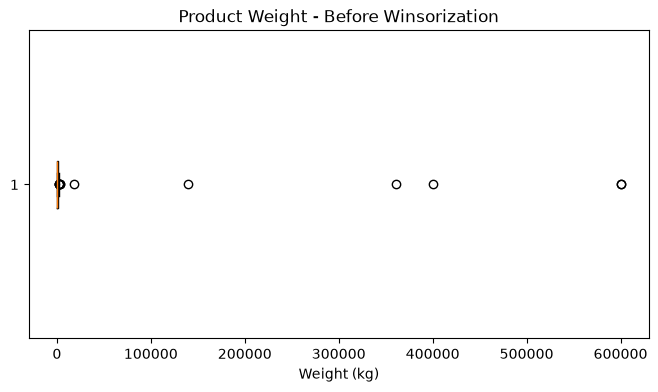

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.boxplot(X_train["Product_Weight"], vert=False)
plt.title("Product Weight - Before Winsorization")
plt.xlabel("Weight (kg)")
plt.show()

In [43]:
Q1 = X_train["Product_Weight"].quantile(0.25)
Q3 = X_train["Product_Weight"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Lower Bound : {lower:.3f}")
print(f"Upper Bound : {upper:.3f}")

Lower Bound : -1497.500
Upper Bound : 2498.500


In [44]:
outliers = X_train[
    (X_train["Product_Weight"] < lower) |
    (X_train["Product_Weight"] > upper)
]

print("Number of outliers:", len(outliers))

Number of outliers: 12


In [45]:
#Step 4.3: Apply Winsorization
X_train["Product_Weight"] = X_train["Product_Weight"].clip(
    lower=lower,
    upper=upper
)

X_test["Product_Weight"] = X_test["Product_Weight"].clip(
    lower=lower,
    upper=upper
)

/tmp/ipykernel_3428/1926947464.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(X_train["Product_Weight"], vert=False)


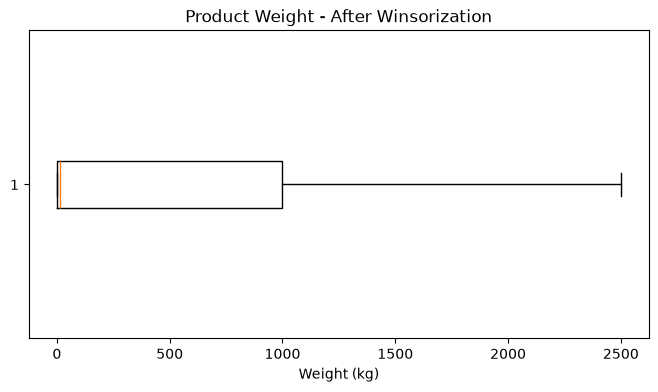

In [46]:
plt.figure(figsize=(8,4))
plt.boxplot(X_train["Product_Weight"], vert=False)
plt.title("Product Weight - After Winsorization")
plt.xlabel("Weight (kg)")
plt.show()

In [47]:
X_train["Product_Weight"].describe()

count     692.000000
mean      363.167180
std       601.179966
min         0.002000
25%         1.000000
50%        15.807694
75%      1000.000000
max      2498.500000
Name: Product_Weight, dtype: float64

#### Encoding start 

In [48]:
X_train["Stage_Level_CO2e_Available"].value_counts()

Stage_Level_CO2e_Available
No     370
Yes    322
Name: count, dtype: int64

In [49]:
binary_map = {
    "No": 0,
    "Yes": 1
}

X_train["Stage_Level_CO2e_Available"] = (
    X_train["Stage_Level_CO2e_Available"]
    .map(binary_map)
)

X_test["Stage_Level_CO2e_Available"] = (
    X_test["Stage_Level_CO2e_Available"]
    .map(binary_map)
)

In [50]:
X_train["Stage_Level_CO2e_Available"].value_counts()

Stage_Level_CO2e_Available
0    370
1    322
Name: count, dtype: int64

In [51]:
# Step 5.2: Target Encoding (Company)
from category_encoders import TargetEncoder

In [52]:
te = TargetEncoder(
    cols=["Company"],
    min_samples_leaf=20,
    smoothing=10
)

X_train = te.fit_transform(X_train, y_train)

X_test = te.transform(X_test)

In [53]:
X_train.head()

,Year,Company,Stage_Level_CO2e_Available,Industry,Product_Weight,PCF_Protocol,Region
818,2015,15951.431092,1,Not used for 2015 reporting,6.4,Not reported,Europe
558,2014,15075.895807,0,Chemicals,1.0,Not reported,Europe
428,2014,15968.350188,1,Paper & Forest Products,1000.0,GHGP,South America
7,2013,16489.317365,0,Other,1000.0,Not reported,Europe
506,2016,10365.445532,0,Household Durables,99.5,TRACI 2.1,North America


In [54]:
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "Industry",
    "PCF_Protocol",
    "Region"
]

encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

encoded_train = encoder.fit_transform(
    X_train[categorical_features]
)

encoded_test = encoder.transform(
    X_test[categorical_features]
)

In [55]:
encoded_train_df = pd.DataFrame(
    encoded_train,
    columns=encoder.get_feature_names_out(categorical_features),
    index=X_train.index
)

encoded_test_df = pd.DataFrame(
    encoded_test,
    columns=encoder.get_feature_names_out(categorical_features),
    index=X_test.index
)

In [56]:
X_train = pd.concat(
    [
        X_train.drop(columns=categorical_features),
        encoded_train_df
    ],
    axis=1
)

X_test = pd.concat(
    [
        X_test.drop(columns=categorical_features),
        encoded_test_df
    ],
    axis=1
)

In [57]:
print(X_train.shape)
print(X_test.shape)



(692, 34)
(174, 34)


In [58]:
import pandas as pd

# Features
X_train.to_csv("X_train_processed.csv", index=False)
X_test.to_csv("X_test_processed.csv", index=False)

# Original target
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

# Log-transformed target
y_train_log.to_csv("y_train_log.csv", index=False)
y_test_log.to_csv("y_test_log.csv", index=False)

print("Processed datasets saved successfully.")

NameError: name 'y_train_log' is not defined

In [60]:
import pandas as pd

# Save processed feature matrices
X_train.to_pickle("X_train_processed.pkl")
X_test.to_pickle("X_test_processed.pkl")

# Save original target variables
y_train.to_pickle("y_train.pkl")
y_test.to_pickle("y_test.pkl")

print("All processed datasets saved successfully.")

All processed datasets saved successfully.


In [ ]:
X_train.head()

In [ ]:
X_test.head()

In [ ]:
X_train.info()

```
##### Step 6: Scaling
This is the only preprocessing step left before training.
Not every feature should be scaled.

##### Scale these:

* `Year`
* `Company` (target-encoded numeric values)
* `Product_Weight`

##### Do **not** scale:

* `Stage_Level_CO2e_Available`
* One-hot encoded columns (`Industry_*`, `Region_*`, `PCF_Protocol_*`)

Those are binary indicators (0/1), and scaling them generally isn't necessary.

#####  My recommendation

Create **two versions** of your data.

##### Version 1 (Scaled)

Use for:
* Linear Regression
* Ridge Regression
* Lasso Regression
* SVR
* KNN (if you decide to try it)

##### Version 2 (Not Scaled)

Use for:
* Decision Tree
* Random Forest
* XGBoost
* LightGBM
* CatBoost
Tree-based models don't need feature scaling.
```

In [ ]:
y_train.describe()

print("Skewness:", y_train.skew())

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(y_train, bins=50)
plt.title("PCF Distribution")
plt.xlabel("PCF")
plt.ylabel("Frequency")
plt.show()

| Skewness    | Interpretation             |
| ----------- | -------------------------- |
| -0.5 to 0.5 | Approximately symmetric    |
| 0.5 to 1    | Moderately skewed          |
| > 1         | Highly skewed              |
| **15.77**   | **Extremely right-skewed** |


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(y_train, bins=50)
plt.title("PCF Distribution")
plt.xlabel("PCF")
plt.ylabel("Frequency")
plt.show()

In [ ]:
plt.figure(figsize=(10,2))

plt.boxplot(y_train, vert=False)

plt.title("PCF Boxplot")

plt.show()

In [ ]:
y_train.describe()

In [ ]:
import numpy as np

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [ ]:
print("Original skewness:", y_train.skew())
print("Log-transformed skewness:", y_train_log.skew())

<details click >
Based on your statistics, **I would choose `log1p` over winsorization for the target (`PCF`)**.

Here's why.

## Your target distribution

| Statistic |     Value |
| --------- | --------: |
| Min       |    0.0004 |
| Q1        |      7.45 |
| Median    |     110.4 |
| Q3        |     1,600 |
| Mean      |    18,790 |
| Max       | 3,718,044 |
| Skewness  | **15.77** |

This tells us:

* The **median is only 110**, but the **maximum is 3.7 million**.
* The mean is much larger than the median because a small number of very large values pull it upward.
* This is characteristic of a **long-tailed positive distribution**.

---

## Why I don't recommend winsorizing the target

Those extreme PCF values are **likely real observations**, not data entry errors.

For example:

* A plastic bottle might have a PCF of a few kilograms of CO₂e.
* A large industrial product could legitimately have a PCF in the hundreds of thousands or millions of kilograms of CO₂e.

If you winsorize the target, you'll cap these valid values and change the prediction problem itself.

In a dissertation, you'd need to justify why those valid observations were altered.

---

## Why `log1p` is preferable

`log1p`:

* Reduces the influence of extremely large values.
* Preserves the order of observations.
* Handles zero values safely (`log1p(0) = 0`).
* Is a standard transformation for positive, right-skewed targets.

This makes it much easier for many regression models to learn the relationship.

Use:

```python
import numpy as np

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)
```

Then check the improvement:

```python
print("Original skewness:", y_train.skew())
print("Log-transformed skewness:", y_train_log.skew())
```

If the skewness drops substantially, that's a good indication the transformation is helping.

---

## How to evaluate models

If you train on the log-transformed target:

```python
model.fit(X_train, y_train_log)
```

Predict:

```python
y_pred_log = model.predict(X_test)
```

Convert predictions back to the original PCF scale:

```python
y_pred = np.expm1(y_pred_log)
```

Then evaluate against the original target:

```python
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
```

This keeps the evaluation metrics in the original units, making them easy to interpret.

---

## My recommendation for your dissertation

I would compare two pipelines:

| Pipeline | Target         |
| -------- | -------------- |
| Baseline | Original `PCF` |
| Enhanced | `log1p(PCF)`   |

Train the same models on both and compare MAE, RMSE, and R² (evaluated on the original PCF scale for the log-transformed model).

This is a stronger experimental design than choosing one approach without evidence. If the log-transformed target consistently improves performance, you'll have clear justification for using it in your final model and a valuable discussion point in your results chapter.


</details>

**Report writing demo here**

<details mreport> 
# 4. Data Preprocessing and Feature Engineering

## 4.1 Overview

Following the data quality assessment and feature selection process, the Carbon Catalogue dataset was prepared for machine learning by applying a structured preprocessing pipeline. The objective of this stage was to improve data quality, reduce feature complexity, minimise the risk of overfitting, and prepare the dataset for accurate product carbon footprint (PCF) prediction. All preprocessing operations were performed after splitting the data into training and testing sets to prevent data leakage.

The preprocessing workflow consisted of feature selection, train-test splitting, feature engineering, outlier treatment, categorical encoding, and target variable transformation.

---

## 4.2 Feature Selection

The original Product Level dataset contained numerous descriptive attributes, many of which were either identifiers or contained high-cardinality categorical values that would substantially increase dimensionality after one-hot encoding.

After analysing feature relevance, the following variables were selected for model development.

| Feature                    | Description                                      |
| -------------------------- | ------------------------------------------------ |
| Year                       | Reporting year of the product carbon footprint   |
| Company                    | Reporting company                                |
| Stage_Level_CO2e_Available | Availability of stage-level emission information |
| Country                    | Country where the company is incorporated        |
| Industry                   | Company's GICS Industry classification           |
| Product_Weight             | Product weight (kg)                              |
| PCF_Protocol               | Carbon footprint calculation protocol            |
| PCF                        | Product Carbon Footprint (Target Variable)       |

Several attributes were excluded because they contained extremely high-cardinality values or did not provide meaningful predictive information. These included PCF-ID, Product Name, Product Detail, Industry Group, Sector, and Company-reported change reason.

---

## 4.3 Train-Test Split

Prior to applying any preprocessing techniques, the dataset was divided into training and testing subsets using an 80:20 ratio.

Splitting the dataset before preprocessing ensured that all data-driven transformations, such as winsorization and target encoding, were learned exclusively from the training data and subsequently applied to the testing data. This prevented information leakage and ensured an unbiased evaluation of model performance.

---

## 4.4 Feature Engineering

### 4.4.1 Country to Region Transformation

The original dataset contained companies from 28 different countries. Several countries contained only a few observations, resulting in sparse categories that would considerably increase the number of dummy variables after one-hot encoding.

To reduce sparsity while preserving geographical information, countries were grouped into broader geographical regions including:

* North America
* Europe
* East Asia
* South Asia
* Southeast Asia
* South America
* Africa
* Oceania

This transformation reduced the number of geographic categories from 28 to 8 without losing meaningful regional information.

---

### 4.4.2 Industry Category Consolidation

The GICS Industry attribute originally consisted of 35 categories. Several industries contained fewer than ten observations.

Industries with fewer than ten products were grouped into a new category labelled **Other**. This reduced category sparsity while maintaining meaningful industrial distinctions.

---

### 4.4.3 PCF Protocol Simplification

The PCF calculation protocol contained numerous infrequently used methodologies.

To reduce unnecessary dimensionality, only the five most frequently occurring protocols were retained:

* ISO
* GHGP
* PAS2050
* TRACI 2.1
* Not Reported

All remaining protocols were grouped into a single **Other** category.

---

## 4.5 Outlier Treatment

Among the selected predictor variables, Product Weight was the only continuous numerical feature requiring outlier analysis.

Outliers were identified using the Interquartile Range (IQR) method.

The calculated thresholds were:

* Lower Bound: -1497.5
* Upper Bound: 2498.5

Only twelve observations exceeded the upper bound, representing approximately 1.7% of the training dataset.

Rather than removing observations, winsorization (value clipping) was applied using the calculated IQR limits. This preserved all samples while reducing the influence of extreme values. The same thresholds learned from the training data were applied to the testing data to maintain consistency and prevent data leakage.

The reporting year variable was not subjected to outlier treatment because it represents a discrete temporal attribute rather than a continuous measurement.

---

## 4.6 Categorical Encoding

Different encoding strategies were selected according to the characteristics of each categorical feature.

### Binary Encoding

The Stage_Level_CO2e_Available attribute consisted of two categories (Yes and No) and was converted into binary values (1 and 0).

---

### Target Encoding

The Company attribute contained 145 unique companies, making one-hot encoding unsuitable because it would substantially increase dimensionality.

Therefore, smoothed target encoding was applied using the training data only. This method replaced each company with a smoothed estimate of its average product carbon footprint while reducing the risk of overfitting associated with companies having only a small number of observations.

---

### One-Hot Encoding

The remaining categorical variables were encoded using one-hot encoding with the first category dropped to avoid redundancy.

The encoded variables included:

* Region
* Industry
* PCF Protocol

Through feature engineering and category consolidation, the final feature space contained only 34 predictor variables instead of more than 120 variables that would have resulted from directly applying one-hot encoding to the original dataset.

---

## 4.7 Target Variable Transformation

Exploratory analysis revealed that the Product Carbon Footprint (PCF) target variable exhibited an extremely right-skewed distribution.

The calculated skewness of the original target variable was:

* Original Skewness = **15.77**

This indicates a highly skewed distribution dominated by a relatively small number of products with exceptionally large carbon footprints.

To address this issue, a logarithmic transformation using the natural logarithm (log1p) was applied:

[
PCF_{log} = \log(1 + PCF)
]

Following transformation, the skewness decreased substantially:

* Transformed Skewness = **0.223**

This produced an approximately symmetric distribution while preserving all observations. Unlike winsorization, the logarithmic transformation retained valid extreme values and reduced their influence without altering the underlying data.

---

## 4.8 Final Machine Learning Dataset

After completing all preprocessing steps, the final machine learning dataset consisted of:

* 692 training observations
* 174 testing observations
* 34 predictor variables
* One continuous target variable (PCF)

The completed preprocessing pipeline included:

1. Feature Selection
2. Train-Test Split
3. Country-to-Region Transformation
4. Industry Category Consolidation
5. PCF Protocol Simplification
6. Winsorization of Product Weight
7. Binary Encoding
8. Smoothed Target Encoding
9. One-Hot Encoding
10. Logarithmic Transformation of the Target Variable

This preprocessing framework produced a compact, high-quality feature set while minimising data leakage, reducing feature sparsity, and improving the suitability of the data for regression-based machine learning models.
</details>

Tips
-----
What to do after XGBoost

Once you've established your XGBoost baseline, compare it against the other regression models you planned:

Linear Regression
Ridge Regression
Lasso Regression
Random Forest Regressor
XGBoost Regressor
Extra Trees Regressor (recommended)
CatBoost Regressor (recommended, especially because it can handle categorical information well)
LightGBM (optional)

Present all models in a comparison table with MAE, RMSE, and R², and identify the best-performing model.

One recommendation

Before moving on to hyperparameter tuning, train every model with the same preprocessing pipeline first. That gives you a fair baseline comparison. Once you've identified the top one or two performers (for example, XGBoost and Random Forest), you can tune only those models using RandomizedSearchCV or GridSearchCV. This is a stronger and more efficient experimental design for your dissertation than tuning every model from the outset.

In [ ]:
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)

y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

y_train_log.to_csv("y_train_log.csv", index=False)
y_test_log.to_csv("y_test_log.csv", index=False)

In [ ]:
# XGBoost
from xgboost import XGBRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [ ]:
# Initialize the XGBoost Regressor
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)

In [ ]:
# Train the model using the log-transformed target
xgb_model.fit(X_train, y_train_log)

In [ ]:
# Predict the log-transformed PCF
y_pred_log = xgb_model.predict(X_test)

In [ ]:
# Convert predictions back to the original PCF scale
y_pred = np.expm1(y_pred_log)

In [ ]:
# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# Root Mean Squared Error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Coefficient of Determination
r2 = r2_score(y_test, y_pred)

In [ ]:
print("=" * 50)
print("XGBoost Regression Performance")
print("=" * 50)

print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

In [ ]:
# Create Feature Importance DataFrame
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

In [ ]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 15 Most Important Features (XGBoost)")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
xgb_results = pd.DataFrame({
    "Model": ["XGBoost"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2]
})

xgb_results

In [ ]:
model.fit(X_train, y_train_log)

y_pred_log = model.predict(X_test)

y_pred = np.expm1(y_pred_log)

r2_score(y_test, y_pred)